Image from https://diode-dataset.org/

Computer Vision Model: https://universe.roboflow.com/microsoft/coco/model/37

Depth Model: https://depth-anything-v2.github.io/


In [ ]:
# Install required libraries
!pip install onnxruntime opencv-python numpy matplotlib pillow inference supervision

In [27]:
import cv2
import numpy as np
import onnxruntime as ort
import matplotlib.pyplot as plt
import torch
from PIL import Image
import time
import os
from pathlib import Path
from transformers import pipeline
from inference import get_model
import supervision as sv

In [18]:
depth_pipe = pipeline(task="depth-estimation", model="depth-anything/Depth-Anything-V2-Small-hf")
image = Image.open("test1.jpg")
depth = pipe(image)["depth"]

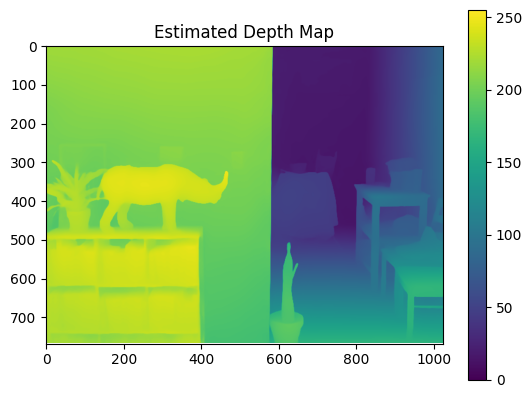

In [19]:
import matplotlib.pyplot as plt

# Display the depth map
plt.imshow(depth)
plt.title("Estimated Depth Map")
plt.colorbar() # Optional: adds a color bar to show depth scale
plt.show()

SupervisionWarnings: BoundingBoxAnnotator is deprecated: `BoundingBoxAnnotator` is deprecated and has been renamed to `BoxAnnotator`. `BoundingBoxAnnotator` will be removed in supervision-0.26.0.


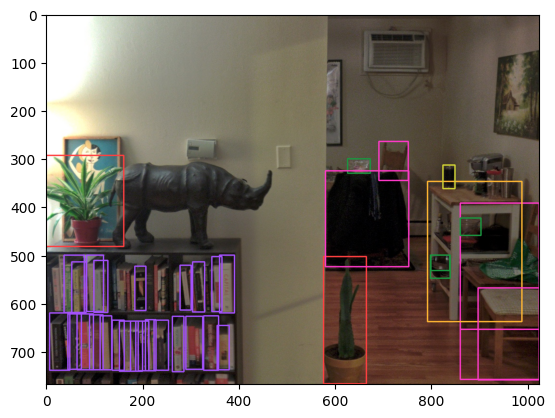

In [ ]:
object_detection_model = get_model(
    model_id="coco/37", 
    api_key=""
)

# Load image
image_path = "test1.jpg"
frame = cv2.imread(image_path)

# will edit later
player_result = object_detection_model.infer(frame, confidence=0.3)[0]
player_detections = sv.Detections.from_inference(player_result)

# Annotate object with Bounding Boxes
box_annotator = sv.BoundingBoxAnnotator(thickness=2) # Use BoundingBoxAnnotator

# Annotate the original 'frame' with the detected boxes
# Store the result in 'annotated_frame_boxes'
annotated_frame_boxes = box_annotator.annotate(
    scene=frame.copy(), # Use frame.copy() to avoid modifying the original
    detections=player_detections
)

plt.imshow(cv2.cvtColor(annotated_frame_boxes, cv2.COLOR_BGR2RGB))
plt.show()



SupervisionWarnings: BoundingBoxAnnotator is deprecated: `BoundingBoxAnnotator` is deprecated and has been renamed to `BoxAnnotator`. `BoundingBoxAnnotator` will be removed in supervision-0.26.0.


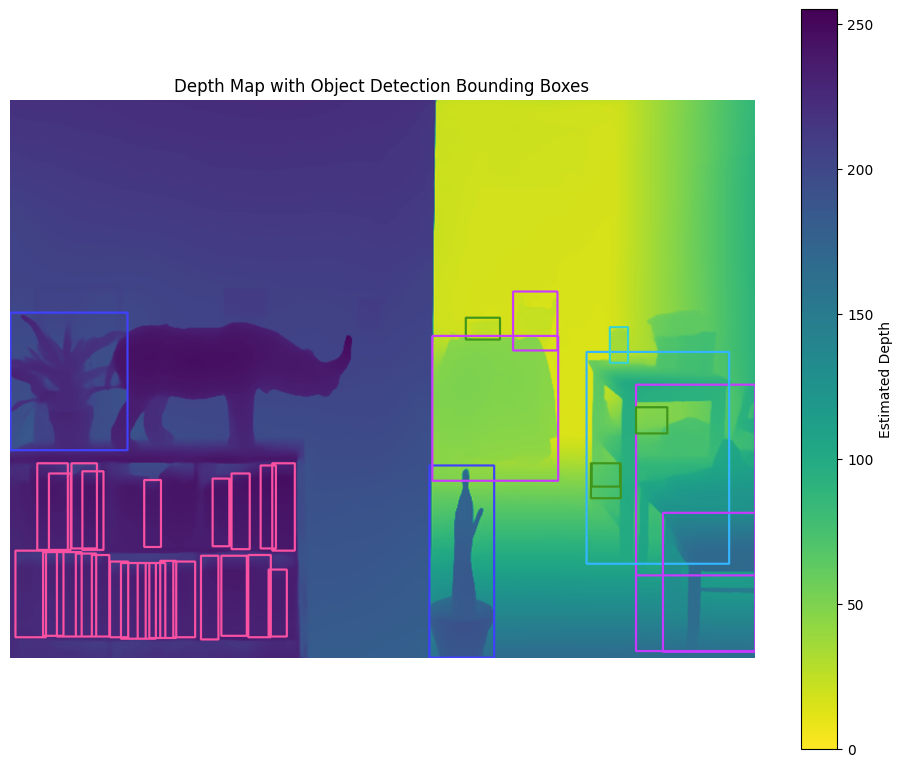

In [ ]:
import matplotlib.cm as cm

depth_array = None
if isinstance(depth, Image.Image):
    depth_array = np.array(depth)
elif isinstance(depth, np.ndarray):
    depth_array = depth.copy()
else:
    raise TypeError(f"Error: 'depth' variable is of unexpected type: {type(depth)}. Cannot proceed.")

# Clean potential NaN/Inf values
if np.isnan(depth_array).any() or np.isinf(depth_array).any():
    print("Warning: NaN or Inf values found in depth map, replacing with 0.")
    # Replace NaN/Inf with 0 or another value like the median/mean if appropriate
    depth_array = np.nan_to_num(depth_array, nan=0.0, posinf=0.0, neginf=0.0)

# Issue with this calculation will fix
vmin = np.min(depth_array)
vmax = np.max(depth_array)
if vmax > vmin:
    norm_depth_array = (depth_array - vmin) / (vmax - vmin)
else:
    norm_depth_array = np.zeros_like(depth_array) 


colormap = cm.get_cmap('viridis')
colored_depth_rgba = colormap(norm_depth_array) 

# Convert to RGB uint8 format (range [0, 255])
colored_depth_rgb_uint8 = (colored_depth_rgba[:, :, :3] * 255).astype(np.uint8)

# Bounding Box Annotator
if 'player_detections' not in locals():
     raise NameError("Error: 'player_detections' not found. Run object detection first.")
else:
    box_annotator = sv.BoundingBoxAnnotator(thickness=2)
    # Annotate the colorized depth map
    annotated_depth_with_boxes = box_annotator.annotate(
        scene=colored_depth_rgb_uint8.copy(), # Annotate the colorized depth map
        detections=player_detections
    )


fig, ax = plt.subplots(figsize=(12, 12))
im = ax.imshow(annotated_depth_with_boxes)
ax.set_title("Depth Map with Object Detection Bounding Boxes")
ax.axis('off')

# Add a colorbar representing the original depth scale
# Use the vmin/vmax calculated before normalization
norm_for_colorbar = plt.Normalize(vmin=vmin, vmax=vmax)
sm = plt.cm.ScalarMappable(cmap=colormap, norm=norm_for_colorbar)
sm.set_array([]) # Necessary for the colorbar
fig.colorbar(sm, ax=ax, label='Estimated Depth', shrink=0.8) # Adjust shrink as needed

plt.show()